# Analise exploratoria e qualidade dos dados

Este notebook descreve os dados fornecidos, verifica a qualidade do merge por CEP e registra hipoteses para a modelagem. Nenhum modelo de Machine Learning e treinado aqui.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from property_value_insights.data_contract import (  # noqa: E402
    load_raw_data,
    validate_historical_frame,
)
from property_value_insights.eda import (  # noqa: E402
    iqr_outlier_summary,
    merge_historical_with_demographics,
    numeric_correlations,
    quality_summary,
    write_quality_report,
)

FIGURE_DIR = PROJECT_ROOT / "reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Carregamento e dicionario de dados

In [2]:
historical, demographics, future = load_raw_data(PROJECT_ROOT / "data/raw")
historical_audit = validate_historical_frame(historical)

quality = pd.concat(
    [
        quality_summary(historical, "historical"),
        quality_summary(demographics, "demographics"),
        quality_summary(future, "future"),
    ],
    ignore_index=True,
)
display(quality)

data_dictionary = pd.DataFrame(
    [
        ("id", "identificador de referencia do registro", "rastreabilidade"),
        ("date", "data da venda historica", "ordenacao e separacao temporal"),
        ("price", "preco observado do imovel", "alvo"),
        ("bedrooms", "quantidade de quartos", "feature fisica"),
        ("bathrooms", "quantidade de banheiros", "feature fisica"),
        ("sqft_living", "area habitavel", "feature fisica"),
        ("sqft_lot", "area do lote", "feature fisica"),
        ("floors", "quantidade de andares", "feature fisica"),
        ("waterfront", "indicador de acesso a agua", "feature categorica"),
        ("view", "indice de qualidade da vista", "feature categorica"),
        ("condition", "indice de condicao do imovel", "feature categorica"),
        ("grade", "classificacao construtiva", "feature categorica/ordinal"),
        ("yr_built", "ano de construcao", "feature temporal"),
        ("zipcode", "codigo postal do imovel", "chave categorica do merge"),
        ("lat / long", "coordenadas geograficas", "localizacao"),
        ("demographics", "indicadores agregados por CEP", "features contextuais"),
    ],
    columns=["variavel", "descricao", "papel"],
)
display(data_dictionary)

data_dictionary_path = PROJECT_ROOT / "reports/data_dictionary.md"
data_dictionary_path.write_text(
    "# Dicionario de dados\n\n"
    "Descricao das variaveis utilizadas na analise exploratoria.\n\n"
    + data_dictionary.to_markdown(index=False)
    + "\n",
    encoding="utf-8",
)
print(f"Dicionario salvo em {data_dictionary_path}")

,dataset,rows,columns,missing_cells,exact_duplicate_rows,unique_zipcodes
0,historical,21613,21,0,0,70
1,demographics,70,27,0,0,70
2,future,100,18,0,0,45


,variavel,descricao,papel
0,id,identificador de referencia do registro,rastreabilidade
1,date,data da venda historica,ordenacao e separacao temporal
2,price,preco observado do imovel,alvo
3,bedrooms,quantidade de quartos,feature fisica
4,bathrooms,quantidade de banheiros,feature fisica
5,sqft_living,area habitavel,feature fisica
6,sqft_lot,area do lote,feature fisica
7,floors,quantidade de andares,feature fisica
8,waterfront,indicador de acesso a agua,feature categorica
9,view,indice de qualidade da vista,feature categorica


Dicionario salvo em C:\iago\desenvolvimento\Desafio Técnico - GenAI\reports\data_dictionary.md


As tabelas a seguir separam identificadores, alvo, features fisicas, localizacao e contexto agregado conforme o contrato de dados.

## 2. Merge por CEP e qualidade estrutural

In [3]:
merged, merge_audit = merge_historical_with_demographics(historical, demographics)
merge_summary = pd.DataFrame(
    [{
        "historical_rows": merge_audit.historical_rows,
        "merged_rows": merge_audit.merged_rows,
        "row_retention_pct": merge_audit.row_retention_pct,
        "historical_zipcodes": merge_audit.historical_zipcodes,
        "matched_zipcodes": merge_audit.matched_zipcodes,
        "zipcode_coverage_pct": merge_audit.zipcode_coverage_pct,
        "unmatched_rows": merge_audit.unmatched_rows,
    }]
)
display(merge_summary)
display(merged.head(3))

missing_by_dataset = pd.DataFrame(
    {
        "historical": historical.isna().sum(),
        "demographics": demographics.isna().sum(),
        "future": future.isna().sum(),
    }
).fillna(0).astype(int)
display(missing_by_dataset[missing_by_dataset.sum(axis=1) > 0])

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "historical",
            "exact_duplicate_rows": historical_audit.exact_duplicate_rows,
            "duplicate_id_keys": historical_audit.duplicate_id_keys,
        },
        {
            "dataset": "demographics",
            "exact_duplicate_rows": int(demographics.duplicated().sum()),
            "duplicate_id_keys": 0,
        },
    ]
)
display(duplicate_summary)

,historical_rows,merged_rows,row_retention_pct,historical_zipcodes,matched_zipcodes,zipcode_coverage_pct,unmatched_rows
0,21613,21613,100.00,70,70,100.00,0


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,...,edctn_some_clg_qty,edctn_assoc_dgre_qty,edctn_bchlr_dgre_qty,edctn_prfsnl_qty,per_urbn,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,...,"4,630.00","1,277.00","2,688.00",952.00,100.00,0.00,0.00,0.00,4.00,8.00,20.00,21.00,5.00,12.00,4.00
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,...,"7,163.00","2,093.00","7,266.00","4,482.00",100.00,0.00,0.00,0.00,2.00,5.00,15.00,20.00,5.00,20.00,12.00
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,...,"3,703.00","1,211.00","3,547.00","1,762.00",100.00,0.00,0.00,0.00,1.00,4.00,13.00,20.00,6.00,19.00,9.00


,historical,demographics,future


,dataset,exact_duplicate_rows,duplicate_id_keys
0,historical,0,176
1,demographics,0,0


O merge manteve a cardinalidade do historico e apresentou cobertura completa dos CEPs observados. Os IDs repetidos nao serao usados como chave primaria nem como feature.

## 3. Distribuicao do preco e valores extremos

,count,mean,std,min,1%,25%,50%,75%,99%,max
price,"21,613.00","540,088.14","367,127.20","75,000.00","153,500.36","321,950.00","450,000.00","645,000.00","1,964,400.00","7,700,000.00"


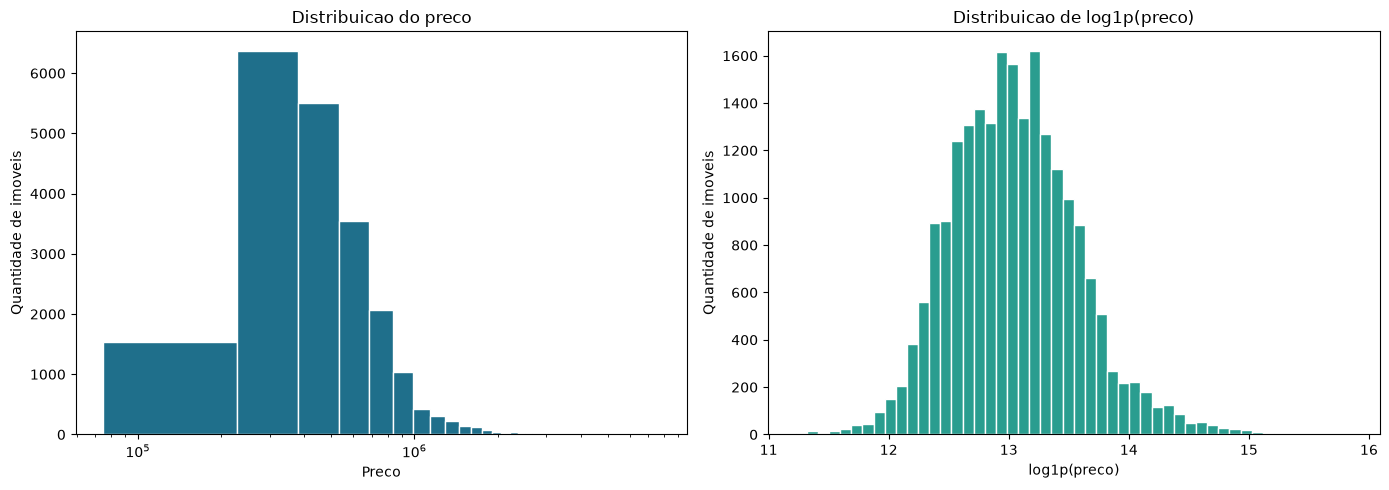

In [4]:
display(historical["price"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(historical["price"], bins=50, color="#1f6f8b", edgecolor="white")
axes[0].set_title("Distribuicao do preco")
axes[0].set_xlabel("Preco")
axes[0].set_ylabel("Quantidade de imoveis")
axes[0].set_xscale("log")
axes[1].hist(np.log1p(historical["price"]), bins=50, color="#2a9d8f", edgecolor="white")
axes[1].set_title("Distribuicao de log1p(preco)")
axes[1].set_xlabel("log1p(preco)")
axes[1].set_ylabel("Quantidade de imoveis")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

A escala logaritmica e relevante porque o preco apresenta assimetria positiva e cauda longa. A transformacao logaritmica sera comparada durante a modelagem.

## 4. Correlacoes numericas

,feature,correlation,abs_correlation
0,sqft_living,0.70,0.70
1,grade,0.67,0.67
2,sqft_above,0.61,0.61
3,sqft_living15,0.59,0.59
4,bathrooms,0.53,0.53
5,view,0.40,0.40
6,sqft_basement,0.32,0.32
7,bedrooms,0.31,0.31
8,lat,0.31,0.31
9,waterfront,0.27,0.27


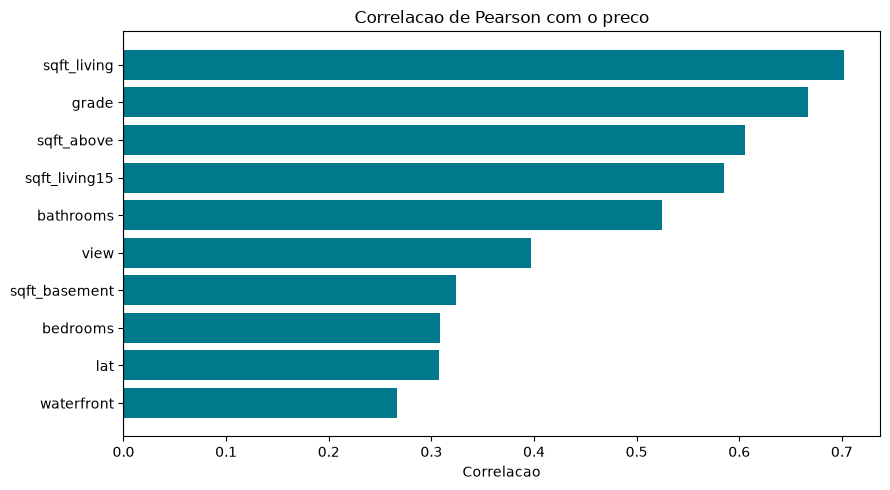

In [5]:
correlations = numeric_correlations(historical, top_n=10)
display(correlations)

fig, ax = plt.subplots(figsize=(9, 5))
ordered = correlations.sort_values("correlation")
colors = ["#d1495b" if value < 0 else "#00798c" for value in ordered["correlation"]]
ax.barh(ordered["feature"], ordered["correlation"], color=colors)
ax.set_title("Correlacao de Pearson com o preco")
ax.set_xlabel("Correlacao")
ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "price_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

Correlacao nao representa causalidade e nao substitui a avaliacao fora da amostra. Os resultados servem para orientar a engenharia de atributos e a comparacao de modelos.

## 5. Localizacao e segmentos

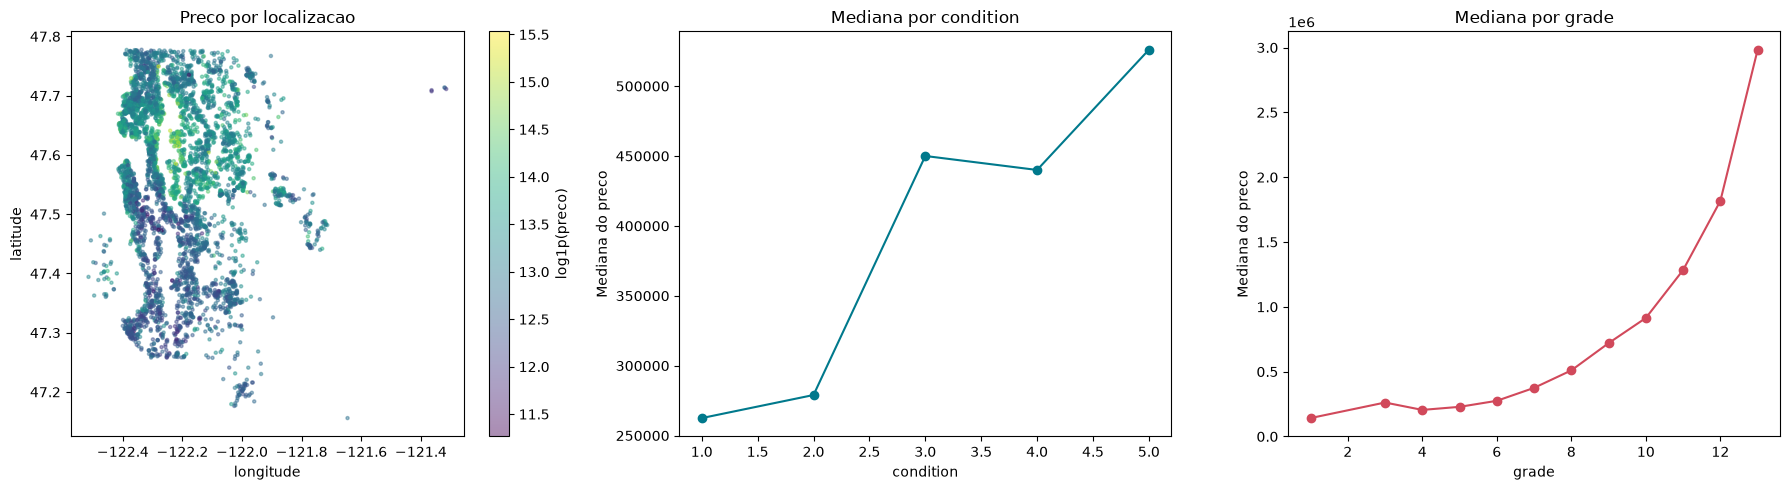

,median_price
condition,
1,"262,500.00"
2,"279,000.00"
3,"450,000.00"
4,"440,000.00"
5,"526,000.00"


,median_price
grade,
1,"142,000.00"
3,"262,000.00"
4,"205,000.00"
5,"228,700.00"
6,"275,276.50"
7,"375,000.00"
8,"510,000.00"
9,"720,000.00"
10,"914,327.00"


In [6]:
geo_sample = historical.sample(n=min(5000, len(historical)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter = axes[0].scatter(
    geo_sample["long"],
    geo_sample["lat"],
    c=np.log1p(geo_sample["price"]),
    s=5,
    alpha=0.45,
    cmap="viridis",
)
axes[0].set_title("Preco por localizacao")
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
fig.colorbar(scatter, ax=axes[0], label="log1p(preco)")

condition_summary = historical.groupby("condition")["price"].median()
grade_summary = historical.groupby("grade")["price"].median()
axes[1].plot(condition_summary.index, condition_summary.values, marker="o", color="#00798c")
axes[1].set_title("Mediana por condition")
axes[1].set_xlabel("condition")
axes[1].set_ylabel("Mediana do preco")

axes[2].plot(grade_summary.index, grade_summary.values, marker="o", color="#d1495b")
axes[2].set_title("Mediana por grade")
axes[2].set_xlabel("grade")
axes[2].set_ylabel("Mediana do preco")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "location_and_segments.png", dpi=150, bbox_inches="tight")
plt.show()

display(condition_summary.rename("median_price").to_frame())
display(grade_summary.rename("median_price").to_frame())

A localizacao e a classificacao construtiva devem ser avaliadas em conjunto com as demais features. A segmentacao por CEP sera importante para verificar generalizacao e risco de erro concentrado em regioes.

## 6. Outliers e hipoteses

In [7]:
outliers = iqr_outlier_summary(historical, ["price", "sqft_living", "sqft_lot"])
display(outliers)

write_quality_report(
    PROJECT_ROOT / "reports/eda_quality.md",
    audit=merge_audit,
    quality=quality,
    outliers=outliers,
    correlations=correlations,
    duplicate_id_keys=historical_audit.duplicate_id_keys,
    exact_duplicate_rows=historical_audit.exact_duplicate_rows,
)
print("Relatorio salvo em reports/eda_quality.md")

,column,q1,q3,lower_bound,upper_bound,outlier_rows,outlier_pct
0,price,"321,950.00","645,000.00","-162,625.00","1,129,575.00",1146,5.30
1,sqft_living,"1,427.00","2,550.00",-257.50,"4,234.50",572,2.65
2,sqft_lot,"5,040.00","10,688.00","-3,432.00","19,160.00",2425,11.22


Relatorio salvo em reports/eda_quality.md


### Hipoteses para a modelagem

1. Area habitavel, classificacao construtiva e localizacao devem explicar parte relevante da variacao de preco.
2. O preco apresenta assimetria suficiente para justificar a comparacao entre alvo original e transformacao logaritmica.
3. As variaveis demograficas agregadas podem acrescentar contexto, mas devem ser avaliadas por ablation e sem interpretacao causal individual.
4. A avaliacao deve preservar a ordem temporal e detalhar o erro por faixa de preco e regiao.

In [8]:
assert len(merged) == len(historical)
assert merge_audit.unmatched_rows == 0
assert merge_audit.zipcode_coverage_pct == 100.0
assert not quality["missing_cells"].gt(0).any()